In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import dask.dataframe as dd
from dask.distributed import Client
client = Client()  # Automatically uses available cores
client

c:\Users\apoor\anaconda3\Lib\site-packages\distributed\node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 65092 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:65092/status,
Dashboard: http://127.0.0.1:65092/status,Workers: 4
Total threads: 16,Total memory: 15.86 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:65093,Workers: 0
Dashboard: http://127.0.0.1:65092/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:65117,Total threads: 4
Dashboard: http://127.0.0.1:65121/status,Memory: 3.96 GiB
Nanny: tcp://127.0.0.1:65096,


2025-10-25 04:48:36,600 - distributed.scheduler - WARNING - Worker failed to heartbeat for 17995s; attempting restart: <WorkerState 'tcp://127.0.0.1:65116', name: 2, status: running, memory: 0, processing: 0>
2025-10-25 04:48:36,815 - distributed.scheduler - WARNING - Worker failed to heartbeat for 17996s; attempting restart: <WorkerState 'tcp://127.0.0.1:65117', name: 0, status: running, memory: 0, processing: 0>
2025-10-25 04:48:36,817 - distributed.scheduler - WARNING - Worker failed to heartbeat for 17996s; attempting restart: <WorkerState 'tcp://127.0.0.1:65118', name: 3, status: running, memory: 0, processing: 0>
2025-10-25 04:48:36,822 - distributed.scheduler - WARNING - Worker failed to heartbeat for 17996s; attempting restart: <WorkerState 'tcp://127.0.0.1:65125', name: 1, status: running, memory: 0, processing: 0>
2025-10-25 04:48:39,198 - distributed.nanny - WARNING - Restarting worker
2025-10-25 04:48:39,202 - distributed.nanny - WARNING - Restarting worker
2025-10-25 04:48

In [36]:
df_jan_path = "D:\datascience\campusx\PROJECTS\yellow_tripdata_2016-01.csv\yellow_tripdata_2016-01.csv"
df_feb_path = "D:\datascience\campusx\PROJECTS\yellow_tripdata_2016-02.csv\yellow_tripdata_2016-02.csv"
df_mar_path = "D:\datascience\campusx\PROJECTS\yellow_tripdata_2016-03.csv\yellow_tripdata_2016-03.csv"

In [88]:
# load the dataframes

df_jan = dd.read_csv(df_jan_path, assume_missing=True, usecols= ['trip_distance','tpep_pickup_datetime', 'pickup_longitude',
       'pickup_latitude','dropoff_longitude', 'dropoff_latitude', 'fare_amount'])
df_feb = dd.read_csv(df_feb_path, assume_missing=True, usecols= ['trip_distance', 'tpep_pickup_datetime','pickup_longitude',
       'pickup_latitude','dropoff_longitude', 'dropoff_latitude', 'fare_amount'])
df_mar = dd.read_csv(df_mar_path, assume_missing=True, usecols= ['trip_distance','tpep_pickup_datetime', 'pickup_longitude',
       'pickup_latitude','dropoff_longitude', 'dropoff_latitude', 'fare_amount'])

In [89]:
df_jan

,tpep_pickup_datetime,trip_distance,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,fare_amount
npartitions=26,,,,,,,
,string,float64,float64,float64,float64,float64,float64
,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...
,...,...,...,...,...,...,...


In [90]:
# concat the three dataframes as one

df_final = dd.concat([df_jan, df_feb, df_mar], axis=0)

# New york bounding box:

min_latitude = 40.60

max_latitude = 40.85

min_longitude = -74.05

max_longitude = -73.70

In [91]:
# set the values of coordinates

min_latitude = 40.60
max_latitude = 40.85
min_longitude = -74.05
max_longitude = -73.70

In [92]:
# fare amount column
fare_amount = df_final["fare_amount"].compute()

In [93]:
# trip distance column
trip_distance = df_final["trip_distance"].compute()

In [94]:
fare_amount.shape[0] / 10000000

3.4499859

In [95]:
percentile_values = np.arange(0.991,1.000, 0.001)
percentile_values

fare_amount.quantile(percentile_values)

0.991        52.00
0.992        52.00
0.993        52.00
0.994        52.00
0.995        54.00
0.996        58.50
0.997        63.00
0.998        69.00
0.999        81.00
1.000    429496.72
Name: fare_amount, dtype: float64

In [96]:
max_fare_amount_val = fare_amount.quantile(percentile_values).iloc[-2].item()
min_fare_amount_val = 0.50

print(min_fare_amount_val)
print(max_fare_amount_val)

0.5
81.0


In [97]:
trip_distance.quantile(percentile_values)

0.991          18.80
0.992          19.00
0.993          19.30
0.994          19.63
0.995          20.04
0.996          20.51
0.997          21.10
0.998          21.90
0.999          24.43
1.000    19072628.80
Name: trip_distance, dtype: float64

In [98]:
# percentile values for trip_distance

min_trip_distance_val = 0.25
max_trip_distance_val = trip_distance.quantile(percentile_values).iloc[-2].item()

print(min_trip_distance_val)                       
print(max_trip_distance_val)

0.25
24.43


# Removing Outliers from the Data


In [99]:
# select data points within the given ranges

df_final = df_final.loc[(df_final["pickup_latitude"].between(min_latitude, max_latitude, inclusive="both")) & 
(df_final["pickup_longitude"].between(min_longitude, max_longitude, inclusive="both")) & 
(df_final["dropoff_latitude"].between(min_latitude, max_latitude, inclusive="both")) & 
(df_final["dropoff_longitude"].between(min_longitude, max_longitude, inclusive="both")), :]

In [100]:
df_final = df_final.loc[(df_final["fare_amount"].between(min_fare_amount_val,max_fare_amount_val,inclusive="both")) & 
(df_final["trip_distance"].between(min_trip_distance_val,max_trip_distance_val,inclusive="both"))]

In [50]:
location_subset = df_final[['pickup_latitude','pickup_longitude', 
                           'dropoff_latitude','dropoff_longitude']]



In [87]:
location_subset.head()

,pickup_latitude,pickup_longitude,dropoff_latitude,dropoff_longitude
0,40.734695,-73.990372,40.732407,-73.981842
1,40.729912,-73.980782,40.716679,-73.944473
2,40.679565,-73.984550,40.788925,-73.950272
3,40.718990,-73.993469,40.657333,-73.962242
4,40.781330,-73.960625,40.758514,-73.977264


In [51]:
location_subset

,pickup_latitude,pickup_longitude,dropoff_latitude,dropoff_longitude
npartitions=82,,,,
,float64,float64,float64,float64
,...,...,...,...
...,...,...,...,...
,...,...,...,...
,...,...,...,...


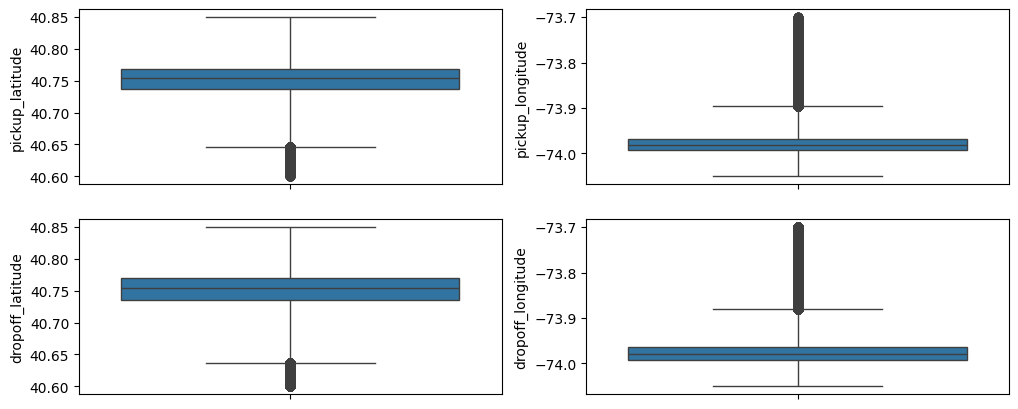

In [52]:
# boxplots for location based columns

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=2, figsize=(12,5))
for i in range(4):
    if i <= 1:
        # plot the boxplot
        sns.boxplot(y=location_subset.iloc[:,i].compute(),ax=ax1[i],whis=3)
    else:
        # plot the boxplot
        sns.boxplot(y=location_subset.iloc[:,i].compute(),ax=ax2[i - 2],whis=3)

# Trip Distance

<Axes: ylabel='trip_distance'>

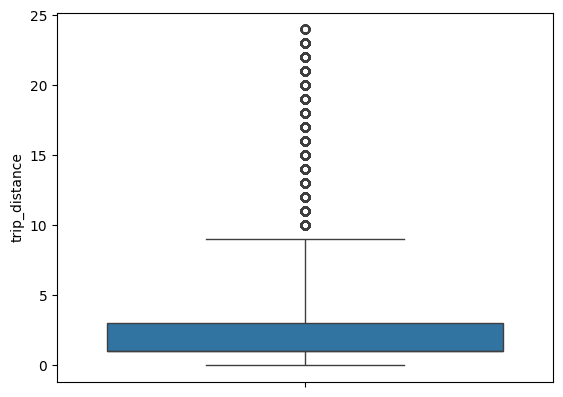

In [53]:
# 🎯 Sample a small portion of data to avoid heavy shuffle and memory usage
trip_distance_sample = df_final["trip_distance"].sample(frac=0.05, random_state=42).compute().astype(int)

# 📊 Plot a boxplot for the sampled trip distances
sns.boxplot(y=trip_distance_sample, whis=3)

# 💬 Comment:
# Using a 5% sample + int conversion ensures the visualization is fast,
# avoids large inter-worker shuffling (red blocks),
# and still accurately represents the trip distance distribution.

# Fare Amount

<Axes: ylabel='fare_amount'>

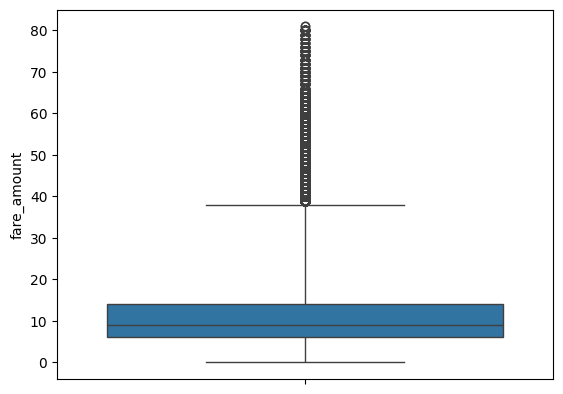

In [54]:
# 🎯 Sample a small portion of data to avoid heavy shuffle and memory usage
trip_fare_sample = df_final["fare_amount"].sample(frac=0.05, random_state=42).compute().astype(int)

# 📊 Plot a boxplot for the sampled trip distances
sns.boxplot(y=trip_fare_sample, whis=3)

# 💬 Comment:
# Using a 5% sample + int conversion ensures the visualization is fast,
# avoids large inter-worker shuffling (red blocks),
# and still accurately represents the trip distance distribution.

In [55]:
pickup_coord_dataset = df_final.loc[:,['pickup_latitude','pickup_longitude']]

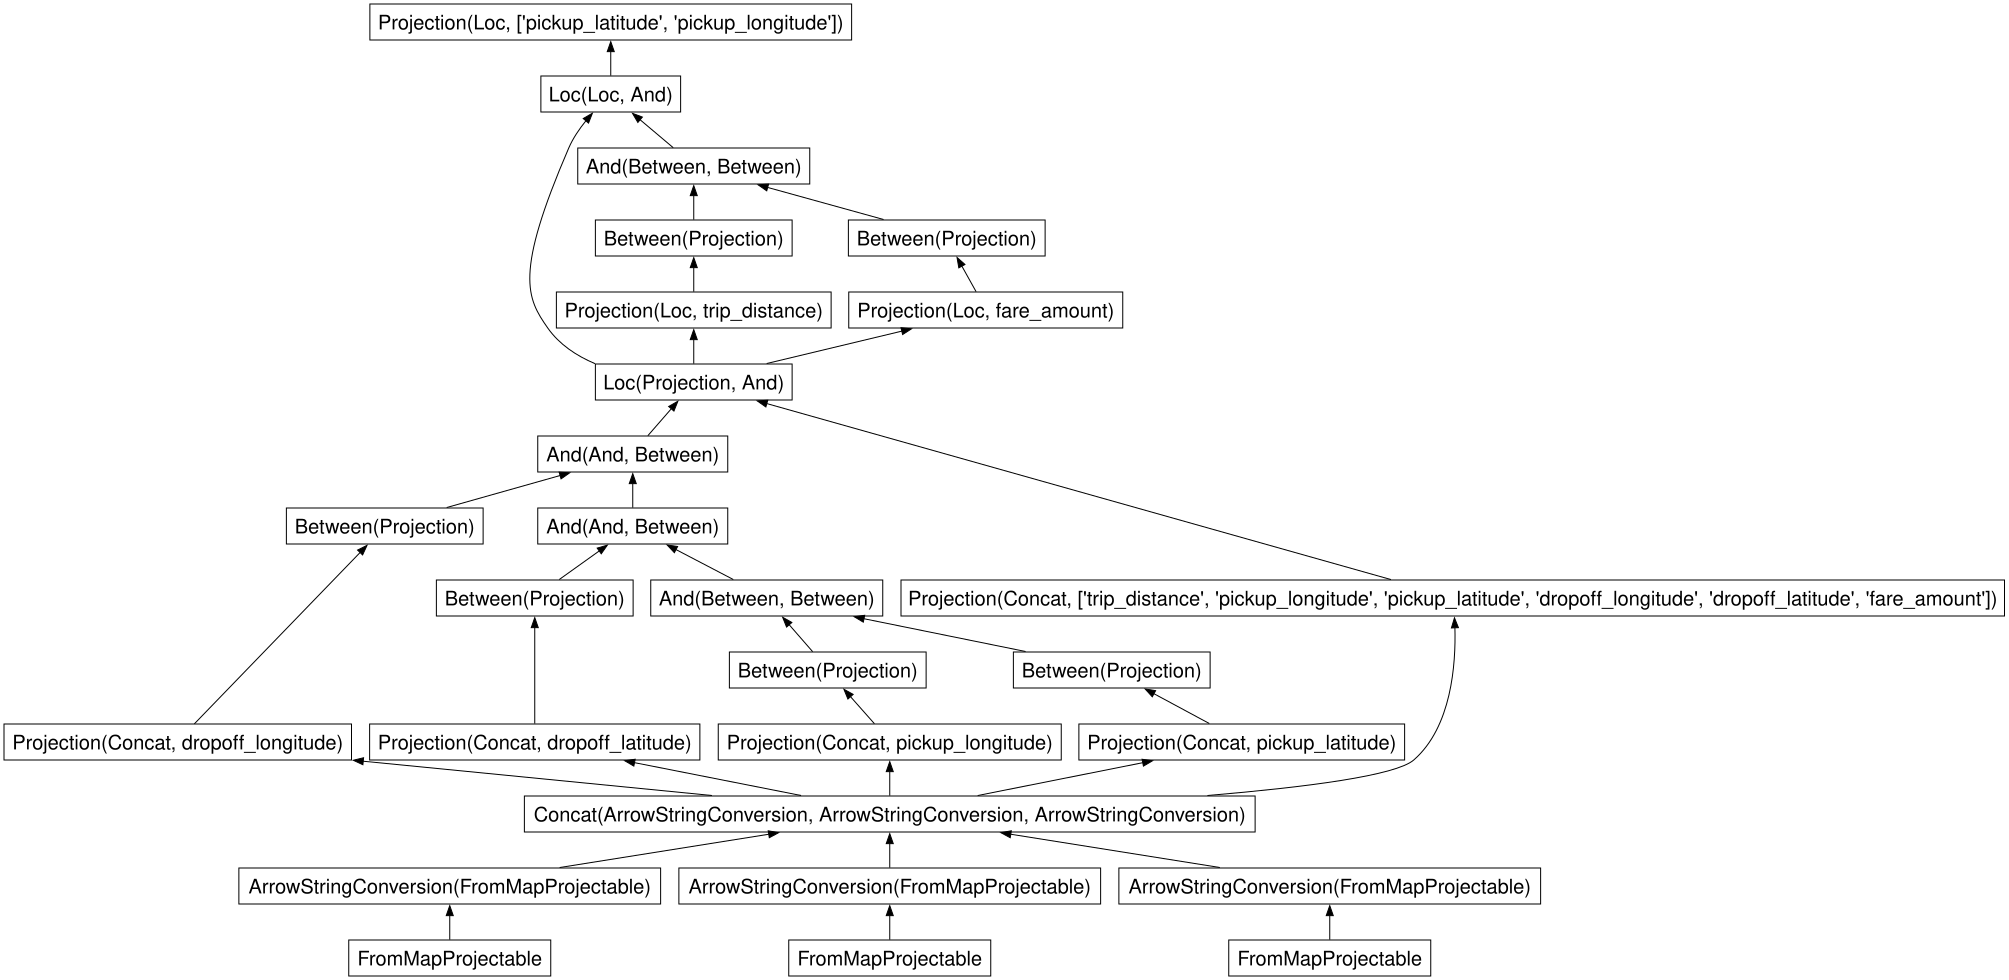

In [56]:
from dask import visualize

pickup_coord_dataset.visualize()

In [57]:
import sys
print(sys.executable)

c:\Users\apoor\anaconda3\python.exe


In [58]:
import shutil
print(shutil.which("dot"))

C:\Program Files\Graphviz\bin\dot.EXE


In [59]:
import os
print(os.environ["PATH"])

c:\Users\apoor\anaconda3;C:\src\flutter\bin\cache\dart-sdk\bin\;C:\Program Files (x86)\Common Files\Oracle\Java\java8path;C:\Program Files (x86)\Common Files\Oracle\Java\javapath;C:\Program Files (x86)\VMware\VMware Player\bin\;C:\Windows\system32;C:\Windows;C:\Windows\System32\Wbem;C:\Windows\System32\WindowsPowerShell\v1.0\;C:\Windows\System32\OpenSSH\;C:\Program Files\NVIDIA Corporation\NVIDIA NvDLISR;C:\Program Files (x86)\NVIDIA Corporation\PhysX\Common;C:\Program Files\Git\cmd;C:\Program Files\Git\mingw64\bin;C:\Program Files\Git\usr\bin;C:\Program Files\Microsoft SQL Server\150\Tools\Binn\;C:\Program Files\Microsoft SQL Server\Client SDK\ODBC\170\Tools\Binn\;C:\Program Files\dotnet\;E:\Matlabb\runtime\win64;E:\Matlabb\bin;C:\WINDOWS\system32;C:\WINDOWS;C:\WINDOWS\System32\Wbem;C:\WINDOWS\System32\WindowsPowerShell\v1.0\;C:\WINDOWS\System32\OpenSSH\;C:\Program Files\MySQL\MySQL Server 8.0;;C:\Program Files\Docker\Docker\resources\bin;C:\Program Files\MySQL\MySQL Shell 8.0\bin\;C:

In [60]:
import os

# ✅ Add Graphviz binary folder to PATH so Python can find 'dot.exe'
os.environ["PATH"] += os.pathsep + r"C:\Program Files\Graphviz\bin"

In [61]:
import shutil
print(shutil.which("dot"))

C:\Program Files\Graphviz\bin\dot.EXE


In [86]:
# form the dataset

pickup_coord_dataset = df_final.loc[:,['pickup_latitude','pickup_longitude']].compute()

print("Shape of the dataset is ", pickup_coord_dataset.shape)

Shape of the dataset is  (33234199, 2)


In [77]:
pickup_coord_dataset

,pickup_latitude,pickup_longitude
0,40.734695,-73.990372
1,40.729912,-73.980782
2,40.679565,-73.984550
3,40.718990,-73.993469
4,40.781330,-73.960625
...,...,...
420269,40.644451,-73.790565
420270,40.641483,-73.788055
420271,40.646736,-73.789154
420273,40.774471,-73.977356


In [82]:
pickup_coord_dataset.to_parquet("data/pickup_coords_parquet.parquet", index=False)

In [101]:
final_df=df_final.drop(columns=['trip_distance', 'dropoff_longitude', 'dropoff_latitude', 'fare_amount'])

In [107]:
final_df

,tpep_pickup_datetime,pickup_longitude,pickup_latitude
npartitions=82,,,
,string,float64,float64
,...,...,...
...,...,...,...
,...,...,...
,...,...,...


In [105]:
final_df.shape[0].compute()

33234199

In [108]:
final_df.to_parquet(
    "data/final_dataset_parquet.parquet",
    write_index=False  # ✅ correct argument for Dask
)